In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


In [2]:
df_ins = pd.read_csv('new_insurance_data.csv')
df_ins.sample(10)


,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
565,48.0,male,40.150,0.0,no,20166.247030,10.0,904825.0,9.807422e+06,1.0,1.543039e+08,southeast,7804.16050
519,39.0,female,26.315,2.0,no,45032.121860,5.0,883689.0,1.536668e+06,1.0,1.459360e+08,northwest,7201.70085
908,60.0,male,24.320,1.0,no,32559.210650,9.0,935446.0,1.193068e+07,1.0,2.610378e+08,northwest,13112.60480
343,27.0,male,18.905,3.0,no,NaN,11.0,860149.0,6.580440e+05,1.0,4.832614e+07,northeast,4827.90495
1050,31.0,male,29.810,0.0,yes,24382.580560,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,southeast,19350.36890
710,51.0,male,32.300,1.0,no,16041.607180,11.0,918635.0,2.058405e+06,1.0,1.081633e+08,northeast,9964.06000
1105,39.0,male,29.925,1.0,yes,49708.651680,24.0,997770.0,1.588656e+07,1.0,5.717591e+08,northeast,22462.04375
1197,19.0,female,33.110,0.0,yes,69805.673940,16.0,1048722.0,4.705632e+07,2.0,1.253476e+09,southeast,34439.85590
259,22.0,female,34.580,2.0,no,48614.570180,11.0,830382.0,8.850428e+06,1.0,5.636327e+07,northeast,3925.75820
593,44.0,male,22.135,2.0,no,7053.497801,5.0,899637.0,7.804162e+06,1.0,1.628453e+08,northeast,8302.53565


In [225]:
# df_ins.info()
# df_ins['Anual_Salary'] = df_ins['Anual_Salary'].fillna(0.00)
# df_ins['Anual_Salary'].apply(lambda x: float(f'{x:.2f}'))
# df_ins['Anual_Salary'].map('{:.2f}'.format).astype('float32')
pd.options.display.float_format = '{:.2f}'.format

In [226]:
# df_ins.info()
# df_ins.describe()
df_ins['Hospital_expenditure'] = df_ins['Hospital_expenditure'].round(2)
df_ins['Claim_Amount'] = df_ins['Claim_Amount'].round(2)
df_ins['Anual_Salary'] = df_ins['Anual_Salary'].round(2)
df_ins['charges'] = df_ins['charges'].round(2)
df_ins.sample(10)

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
1332,60.00,male,32.80,0.00,yes,77277.99,40.00,1095960.00,148034634.60,2.00,2780642185.00,southwest,52590.83
726,54.00,male,30.21,0.00,no,28219.05,6.00,934704.00,6333271.14,1.00,109443967.20,northwest,10231.50
423,42.00,male,26.90,0.00,no,36424.73,16.00,869175.00,3652797.56,1.00,89384855.70,southwest,5969.72
154,20.00,male,31.13,2.00,no,16032.87,7.00,769255.00,1599068.76,1.00,24412621.85,southeast,2566.47
667,51.00,male,22.42,0.00,no,53371.17,19.00,899899.00,6456531.63,1.00,126177423.50,northeast,9361.33
882,60.00,female,NaN,0.00,no,35152.81,15.00,941149.00,10308448.01,1.00,191354461.70,southeast,12629.90
438,34.00,female,29.26,3.00,no,28578.50,18.00,886628.00,8616322.99,1.00,66638916.07,southeast,6184.30
95,21.00,female,39.49,0.00,no,46294.14,12.00,759047.00,8618011.07,0.00,49453135.00,southeast,2026.97
1152,64.00,male,23.76,0.00,yes,24815.79,28.00,1021610.00,25844860.01,2.00,817813402.70,southeast,26926.51
850,54.00,female,28.88,2.00,no,16717.32,16.00,937451.00,10926182.51,1.00,175279630.30,northeast,12096.65


In [227]:
df_ins.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [228]:
df_ins.columns = df_ins.columns.str.lower()

In [229]:
[c.lower() for c in df_ins.columns]
# .apply(lambda x: x.lower())

['age',
 'sex',
 'bmi',
 'children',
 'smoker',
 'claim_amount',
 'past_consultations',
 'num_of_steps',
 'hospital_expenditure',
 'number_of_past_hospitalizations',
 'anual_salary',
 'region',
 'charges']

In [3]:
df_ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [4]:
df_ins.describe()

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1329.000000,1335.000000,1333.000000,1324.000000,1332.000000,1.335000e+03,1.334000e+03,1336.000000,1.332000e+03,1338.000000
mean,39.310008,30.665112,1.090773,33361.327180,15.216216,9.100047e+05,1.584179e+07,1.060629,3.696849e+08,13270.422265
std,14.034818,6.101690,1.201856,15617.288337,7.467723,9.188612e+04,2.669305e+07,0.533583,5.668843e+08,12110.011237
min,18.000000,15.960000,0.000000,1920.136268,1.000000,6.954300e+05,2.945253e+04,0.000000,2.747072e+06,1121.873900
25%,27.000000,26.302500,0.000000,20768.860390,9.000000,8.471995e+05,4.077633e+06,1.000000,7.701932e+07,4740.287150
50%,39.000000,30.400000,1.000000,33700.310675,15.000000,9.143000e+05,7.490337e+06,1.000000,1.419361e+08,9382.033000
75%,51.000000,34.687500,2.000000,45052.331957,20.000000,9.716840e+05,1.084082e+07,1.000000,3.243499e+08,16639.912515
max,64.000000,53.130000,5.000000,77277.988480,40.000000,1.107872e+06,2.616317e+08,3.000000,4.117197e+09,63770.428010


EDA - Exploratory Data Analysis

Data Cleaning
Datatypes
Null Values
Duplicate
Dealing with outliers
visual analysis


In [231]:
# Data Cleaning
# remove duplicates

# df_ins.isnull().sum().sum()
# df_ins.count() #dropna()
# df_ins[df_ins.isnull().sum(axis=1) > 0]
# df_ins.isnull()

df_ins.isnull().sum(axis=1).sum()
df_ins2 = df_ins[:]
df_ins = df_ins.dropna()
df_ins.isnull().sum(axis=1).sum()


np.int64(0)

In [232]:
df_ins[df_ins.isnull().sum(axis=1) > 0]
# df_ins.dropna()

,age,sex,bmi,children,smoker,claim_amount,past_consultations,num_of_steps,hospital_expenditure,number_of_past_hospitalizations,anual_salary,region,charges


In [233]:
# df_ins = df_ins2[:]
# df_ins = df_ins.fillna(0.00)

# df_ins.drop(index=[2,3,1])

In [234]:
df_ins.sum(numeric_only=True)

,0
age,50733.00
bmi,39453.95
children,1409.00
claim_amount,43112671.16
past_consultations,19623.00
num_of_steps,1172943252.00
hospital_expenditure,20333685330.53
number_of_past_hospitalizations,1375.00
anual_salary,479790000088.10
charges,17202135.21


In [235]:
# np.median(df_ins['age'])
df_ins

,age,sex,bmi,children,smoker,claim_amount,past_consultations,num_of_steps,hospital_expenditure,number_of_past_hospitalizations,anual_salary,region,charges
0,18.00,male,23.21,0.00,no,29087.54,17.00,715428.00,4720920.99,0.00,55784970.05,southeast,1121.87
1,18.00,male,30.14,0.00,no,39053.67,7.00,699157.00,4329831.68,0.00,13700885.19,southeast,1131.51
2,18.00,male,33.33,0.00,no,39023.63,19.00,702341.00,6884860.77,0.00,73523107.27,southeast,1135.94
3,18.00,male,33.66,0.00,no,28185.39,11.00,700250.00,4274773.55,0.00,75819679.60,southeast,1136.40
4,18.00,male,34.10,0.00,no,14697.86,16.00,711584.00,3787293.92,0.00,23012320.01,southeast,1137.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.00,female,35.53,0.00,yes,63142.25,32.00,1091267.00,170380500.50,2.00,3101107370.00,northwest,55135.40
1334,31.00,female,38.09,1.00,yes,43419.95,31.00,1107872.00,201515184.80,2.00,3484216117.00,northeast,58571.07
1335,52.00,male,34.48,3.00,yes,52458.92,25.00,1092005.00,223644981.30,2.00,3640806683.00,northwest,60021.40
1336,45.00,male,30.36,0.00,yes,69927.52,34.00,1106821.00,252892382.60,3.00,4006358505.00,southeast,62592.87


In [236]:
# df_ins.duplicated().sum()
df_ins = df_ins.drop_duplicates()

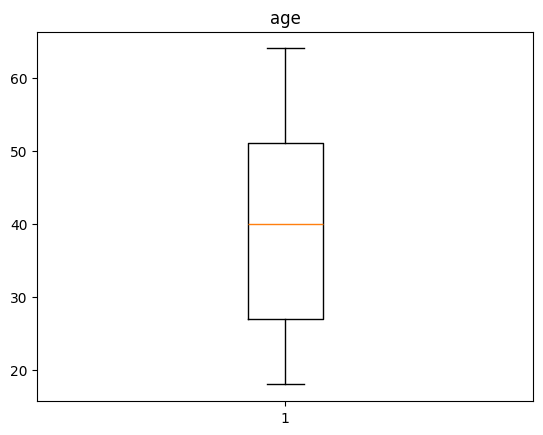

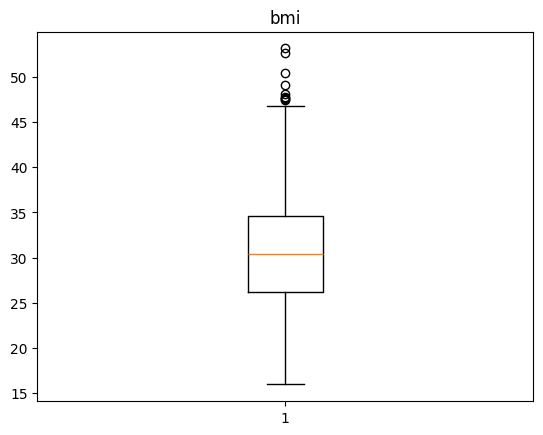

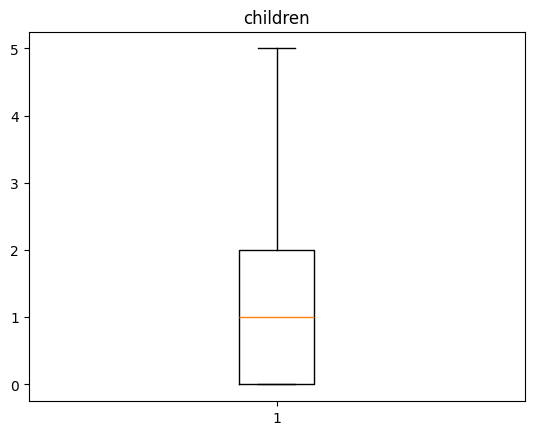

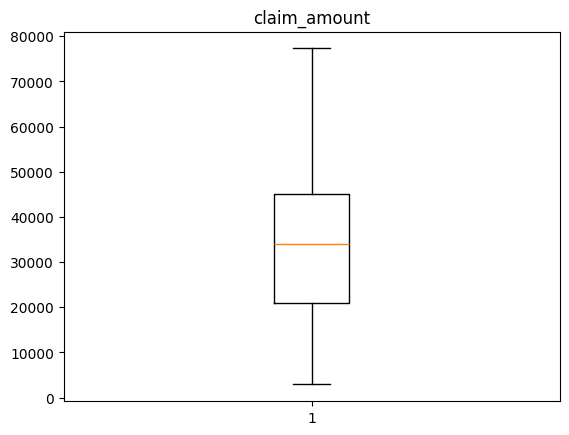

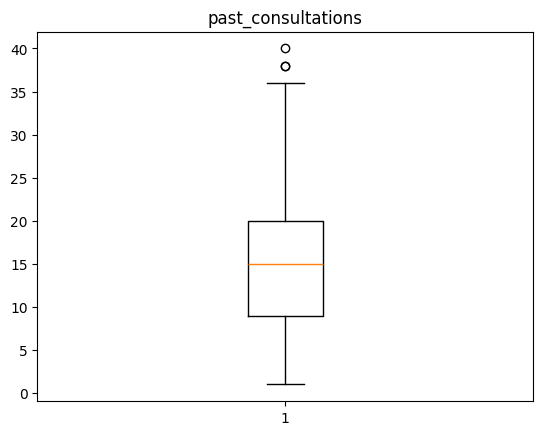

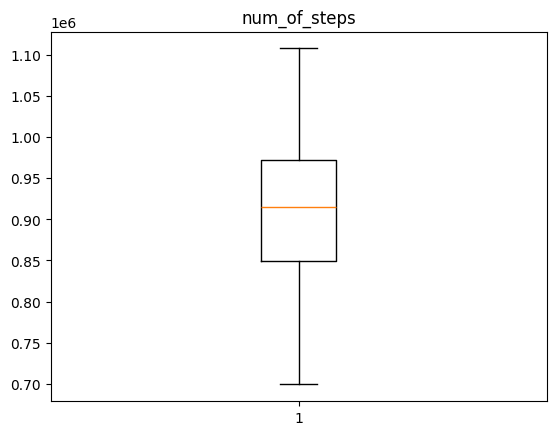

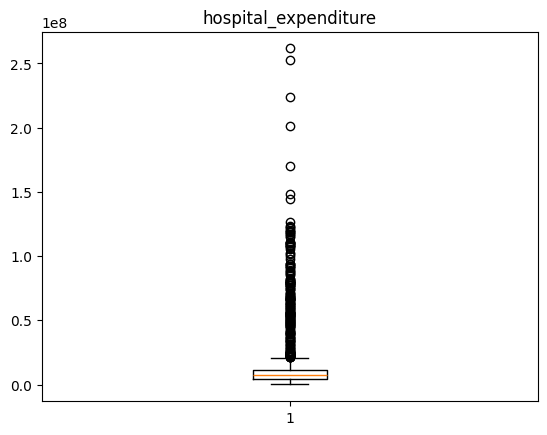

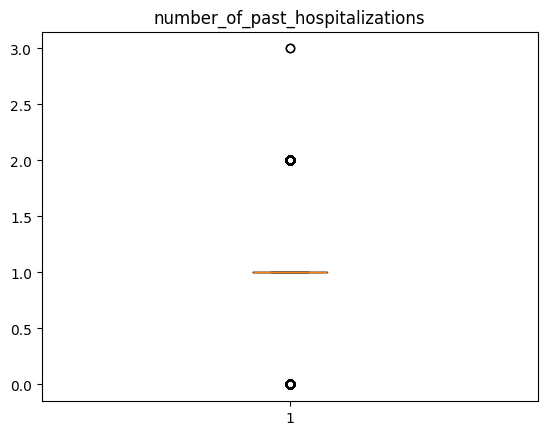

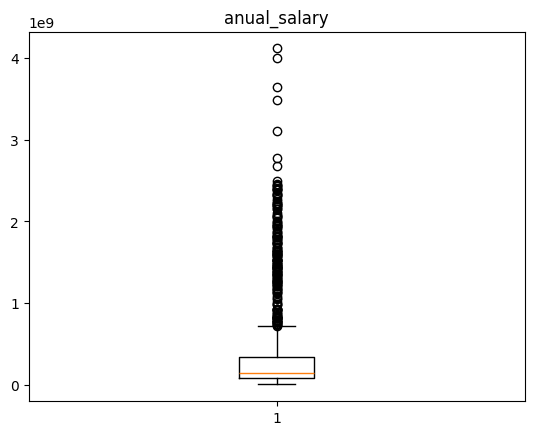

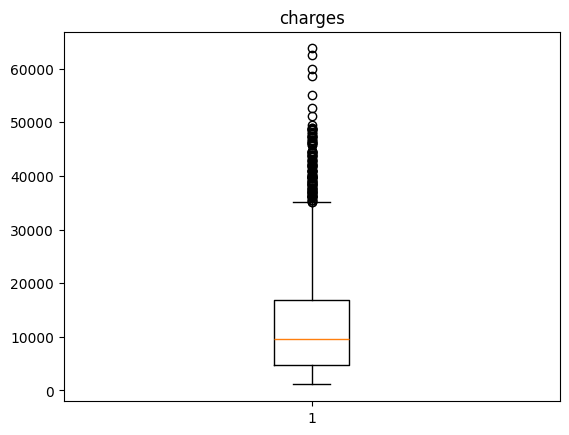

In [237]:
for c in df_ins.columns:
  if df_ins[c].dtype != 'object':
    plt.boxplot(df_ins[c])
    plt.title(c)
    plt.show()




In [238]:
# df_ins['number_of_past_hospitalizations'].value_counts()
df_ins.columns = df_ins.columns.str.lower()

In [239]:
# outliers :
out_cols=['bmi', 'past_consultations', 'hospital_expenditure', 'anual_salary', 'charges']

for c in out_cols:
  # q1 = np.quantile(df_ins[c], 0.25)
  q1 = df_ins[c].quantile(0.25)
  # q3 = np.quantile(df_ins[c], 0.75)
  q3 = df_ins[c].quantile(0.75)
  iqr = q3 - q1
  lower_limit = q1 - iqr * 1.5
  upper_limit = q3 + iqr * 1.5
  df_ins = df_ins[(df_ins[c] >= lower_limit) & (df_ins[c] <= upper_limit)]

# df_ins

In [240]:
# df_ins.info()
print(df_ins.shape, df_ins.size)

(986, 13) 12818


In [241]:
# Data preprocessing, Label Encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [242]:
df_ins['sex'] = le.fit_transform(df_ins['sex'])
df_ins['smoker'] = le.fit_transform(df_ins['smoker'])
df_ins['region'] = le.fit_transform(df_ins['region'])


In [243]:
# df_ins.info()
# df_ins['smoker'].value_counts()
df_ins['region'].value_counts().sort_values(axis=0)
# sort_index(axis=1, ascending=True)
# sort_values(by=['count'],ascending=[True])

,count
region,
0,241
1,247
2,248
3,250


In [244]:
# correlation
#VIF- variance inflation factor
#RFE -- Recursive Feature Elimination
# etc

In [245]:
# Correlation : -1 to +1 , tells the strength and direction of relation,
# +ve highvalue - Strong positive correlation (positive trend)
# -ve high value - strong negative correlation (negative trend)
df_ins.corr()

,age,sex,bmi,children,smoker,claim_amount,past_consultations,num_of_steps,hospital_expenditure,number_of_past_hospitalizations,anual_salary,region,charges
age,1.00,-0.00,0.16,0.05,-0.21,0.11,0.18,0.76,0.16,0.53,0.51,0.02,0.68
sex,-0.00,1.00,0.01,0.02,0.02,-0.03,0.00,-0.06,-0.00,-0.08,-0.03,-0.02,-0.04
bmi,0.16,0.01,1.00,0.01,-0.20,0.01,0.02,0.04,0.01,0.02,0.01,0.16,0.02
children,0.05,0.02,0.01,1.00,-0.03,0.04,0.04,0.22,-0.01,0.31,0.07,0.05,0.13
smoker,-0.21,0.02,-0.20,-0.03,1.00,0.14,0.14,0.30,0.27,0.08,0.51,-0.02,0.44
claim_amount,0.11,-0.03,0.01,0.04,0.14,1.00,0.07,0.19,0.05,0.11,0.17,0.00,0.19
past_consultations,0.18,0.00,0.02,0.04,0.14,0.07,1.00,0.27,0.09,0.14,0.27,0.02,0.29
num_of_steps,0.76,-0.06,0.04,0.22,0.30,0.19,0.27,1.00,0.31,0.72,0.79,-0.04,0.94
hospital_expenditure,0.16,-0.00,0.01,-0.01,0.27,0.05,0.09,0.31,1.00,0.13,0.38,0.02,0.37
number_of_past_hospitalizations,0.53,-0.08,0.02,0.31,0.08,0.11,0.14,0.72,0.13,1.00,0.37,-0.05,0.53


# Feature Selection

# correlation
#VIF- variance inflation factor
#RFE -- Recursive Feature Elimination

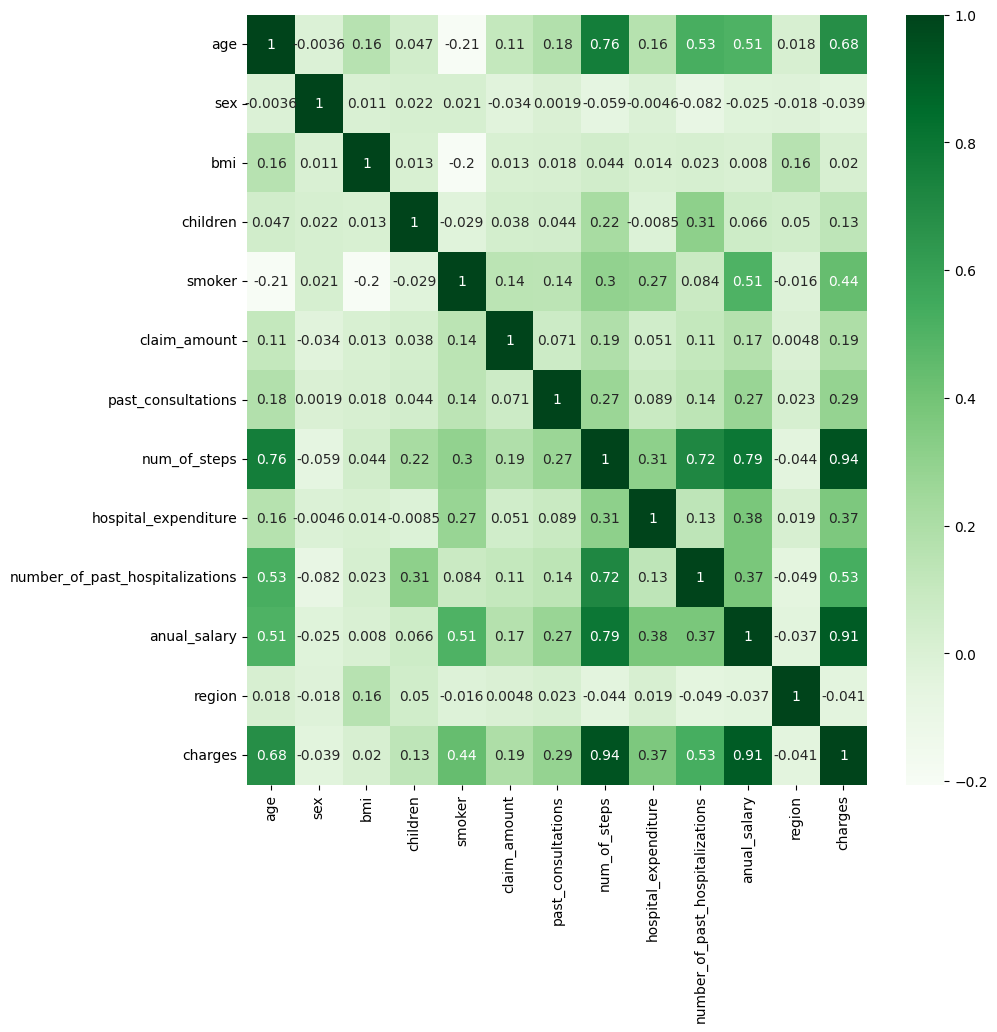

In [246]:
plt.figure(figsize=(10,10))
sns.heatmap(df_ins.corr(), annot=True, cmap='Greens')
plt.show()


**`MODEL BUILDING`**

In [247]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()

In [248]:
# df_ins2.iloc[1,2] = 30.15

In [249]:
#Define Independent and dependent variables
indep_cols = ['age', 'num_of_steps', 'number_of_past_hospitalizations', 'anual_salary', 'smoker']
X = df_ins[indep_cols]
y = df_ins['charges']


In [250]:
# X.isnull().sum()
# y.isnull().sum()

In [251]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [252]:
# x_train.shape
# x_test.shape
# y_train.shape
# y_test.shape


In [253]:
# x_train.isnull().sum().sum()
y_train.isnull().sum()

np.int64(0)

# Model Building

In [254]:
from sklearn.linear_model import LinearRegression

In [255]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [256]:
y_pred = model.predict(x_test)

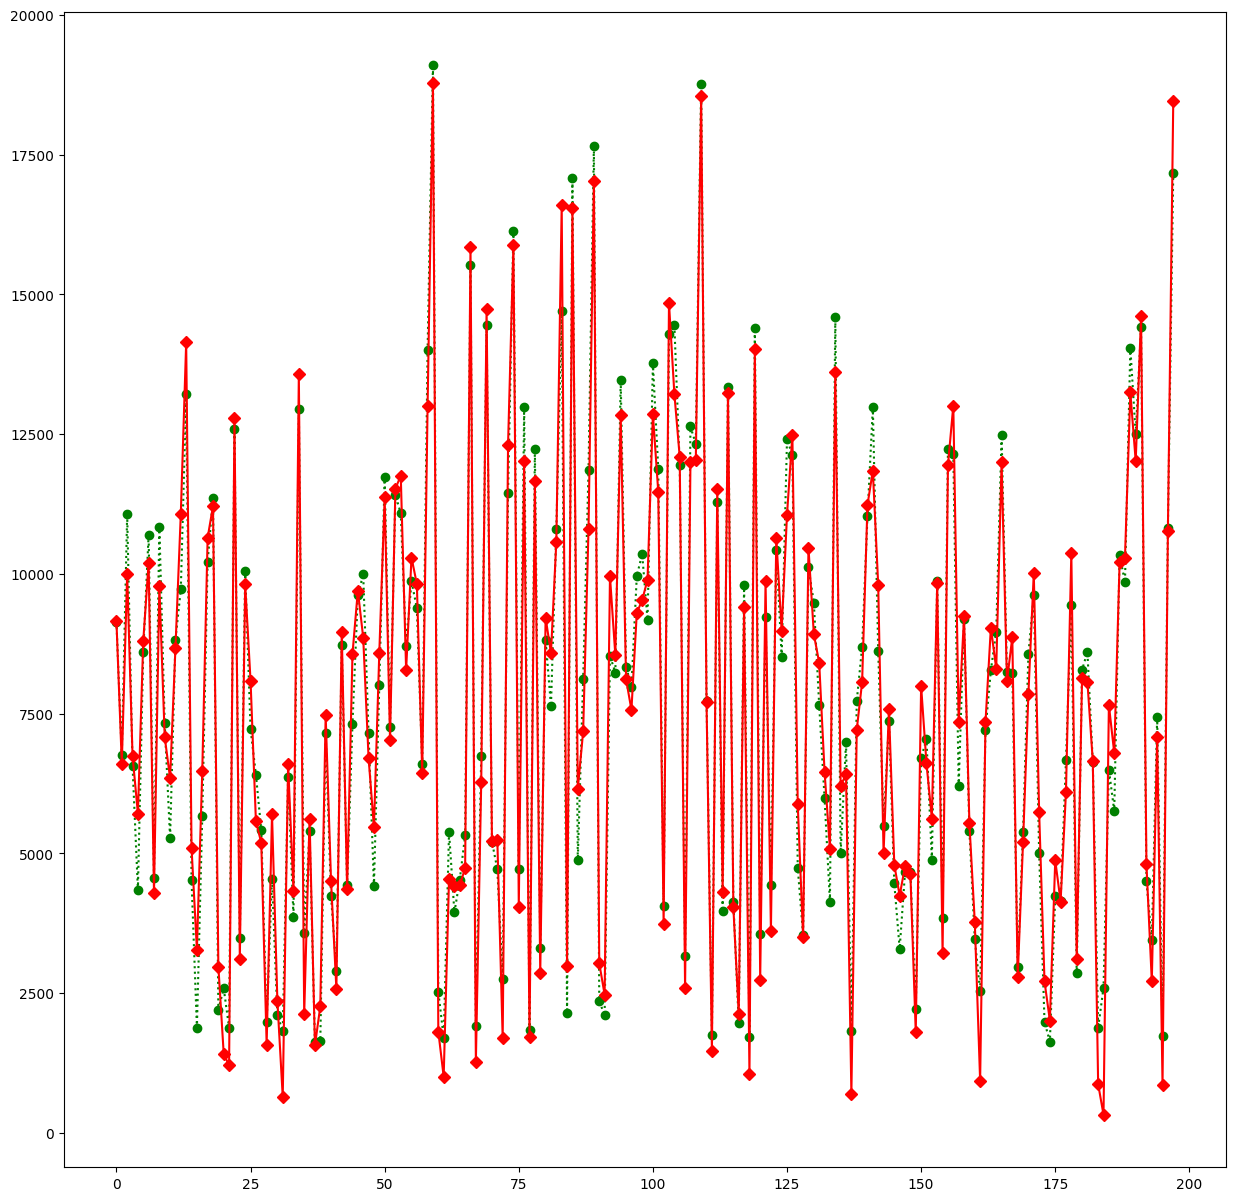

In [257]:
plt.figure(figsize=(15,15))
plt.plot(pd.Series(y_test).reset_index().index, y_test, 'g:o')
plt.plot(pd.Series(y_pred).reset_index().index, y_pred,'r-D')
plt.show()


# Evaluate performance of model

Check RMSE

check accuracy



In [258]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import r2_score


In [259]:
# Root Mean Squared Error - RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

704.0416805019321


In [260]:
type(y_test)

pandas.core.series.Series

In [261]:
# accuracy_score(y_test, y_pred, normalize=False)

In [262]:
# print(f'accuracy_score:', accuracy_score(y_test, y_pred))
# print(f'classification report : {classification_report(y_test, y_pred)}')
# confusion_matrix(y_test, y_pred)

In [263]:
R2_score = r2_score(y_test, y_pred)
R2_score

0.9704964906627044

In [264]:
df_ins_error = pd.DataFrame(data={'Actual': y_test, 'Predicted': y_pred, 'Error': np.abs(y_pred - y_test)})
df_ins_error

,Actual,Predicted,Error
653,9144.56,9155.60,11.04
486,6753.04,6607.56,145.48
775,11070.54,9998.51,1072.03
471,6571.02,6750.40,179.38
295,4350.51,5712.35,1361.84
...,...,...,...
226,3443.06,2711.83,731.23
541,7443.64,7080.75,362.89
60,1727.78,864.29,863.49
761,10825.25,10763.93,61.32
